In [23]:
import os
import json
import pandas as pd

# 경로 설정
base_path = r"C:\Users\home\Desktop\AI_study\data"

print("데이터 내부 전수 조사 중... (파일을 하나씩 열어보는 중이라 시간이 좀 걸립니다)")

stats = []

# 1. 모든 폴더를 끝까지 파고들어 .json 파일을 찾습니다.
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith('.json'):
            file_path = os.path.join(root, file)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    
                    # 데이터 구조가 조금씩 달라도 유연하게 처리
                    item = {}
                    if 'images' in data and isinstance(data['images'], list) and len(data['images']) > 0:
                        item = data['images'][0]
                    elif 'drug_N' in data: 
                        item = data
                    
                    # 핵심 정보 추출
                    if item.get('drug_N') or item.get('dl_mapping_code'):
                        stats.append({
                            'drug_code': item.get('drug_N') or item.get('dl_mapping_code'), # 약 코드
                            'drug_name': item.get('dl_name'),  # 약 이름 (한글)
                            'angle': item.get('camera_la'),    # 촬영 각도
                            'direction': item.get('drug_dir'), # 앞면/뒷면
                            'light': item.get('light_color'),  # 조명 색상
                            'bg_color': item.get('back_color') # 배경 색상
                        })
            except:
                continue # 깨진 파일은 패스

# 2. 분석 결과 출력
if stats:
    df = pd.DataFrame(stats)
    
    unique_codes = df['drug_code'].nunique()
    unique_names = df['drug_name'].nunique()
    
    print("\n" + "="*50)
    print("📊 [팩트 체크] 데이터셋 실체 분석 결과")
    print("="*50)
    print(f"1. 발견된 총 파일 개수: {len(df)} 개")
    print(f"2. 실제 약물 코드(ID) 수 : {unique_codes} 종")
    print(f"3. 실제 약물 이름(Name) 수: {unique_names} 종")
    print("-" * 50)
    
    # 사용자님 말씀하신 '곱하기 조건'들이 실제로 존재하는지 확인
    print("[데이터 증식 요인 (Multiplier)]")
    print(f"▶ 촬영 각도: {df['angle'].nunique()}가지 {df['angle'].unique()}")
    print(f"▶ 촬영 방향: {df['direction'].nunique()}가지 {df['direction'].unique()}")
    print(f"▶ 조명 종류: {df['light'].nunique()}가지 {df['light'].unique()}")
    print(f"▶ 배경 종류: {df['bg_color'].nunique()}가지 {df['bg_color'].unique()}")
    
    print("-" * 50)
    # 진짜 평균 몇 장인지 계산
    if unique_codes > 0:
        print(f"🚀 결론: 약 1종류당 평균 {len(df)/unique_codes:.1f}장의 데이터가 존재합니다.")
    
    # 혹시 약 코드랑 이름이랑 개수가 다르면 (예: 코드는 같은데 이름이 다른 경우)
    if unique_codes != unique_names:
        print(f"⚠️ 주의: 약 코드({unique_codes}개)와 이름({unique_names}개)의 개수가 다릅니다! 동명이인 약이 있을 수 있습니다.")
else:
    print("❌ 경로에서 분석 가능한 JSON 파일을 하나도 못 찾았습니다.")

데이터 내부 전수 조사 중... (파일을 하나씩 열어보는 중이라 시간이 좀 걸립니다)

📊 [팩트 체크] 데이터셋 실체 분석 결과
1. 발견된 총 파일 개수: 6774 개
2. 실제 약물 코드(ID) 수 : 76 종
3. 실제 약물 이름(Name) 수: 76 종
--------------------------------------------------
[데이터 증식 요인 (Multiplier)]
▶ 촬영 각도: 3가지 [70 75 90]
▶ 촬영 방향: 2가지 ['앞면' '뒷면']
▶ 조명 종류: 1가지 ['주백색']
▶ 배경 종류: 1가지 ['연회색 배경']
--------------------------------------------------
🚀 결론: 약 1종류당 평균 89.1장의 데이터가 존재합니다.


데이터 전수 로딩 중... (잠시만 기다려주세요)

📊 총 발견된 약물 클래스: 76개


,label_name,count
No.,,
1,마그밀정(수산화마그네슘) (K-000250),540
2,알마겔정(알마게이트)(수출명:유한가스트라겔정) (K-001866),537
3,게보린정 300mg/PTP (K-000573),450
4,다보타민큐정 10mg/병 (K-012778),276
5,트루비타정 60mg/병 (K-019552),273
...,...,...
72,제미메트서방정 50/1000mg (K-034597),3
73,자누메트엑스알서방정 100/1000mg (K-031885),3
74,카나브정 60mg (K-027777),3


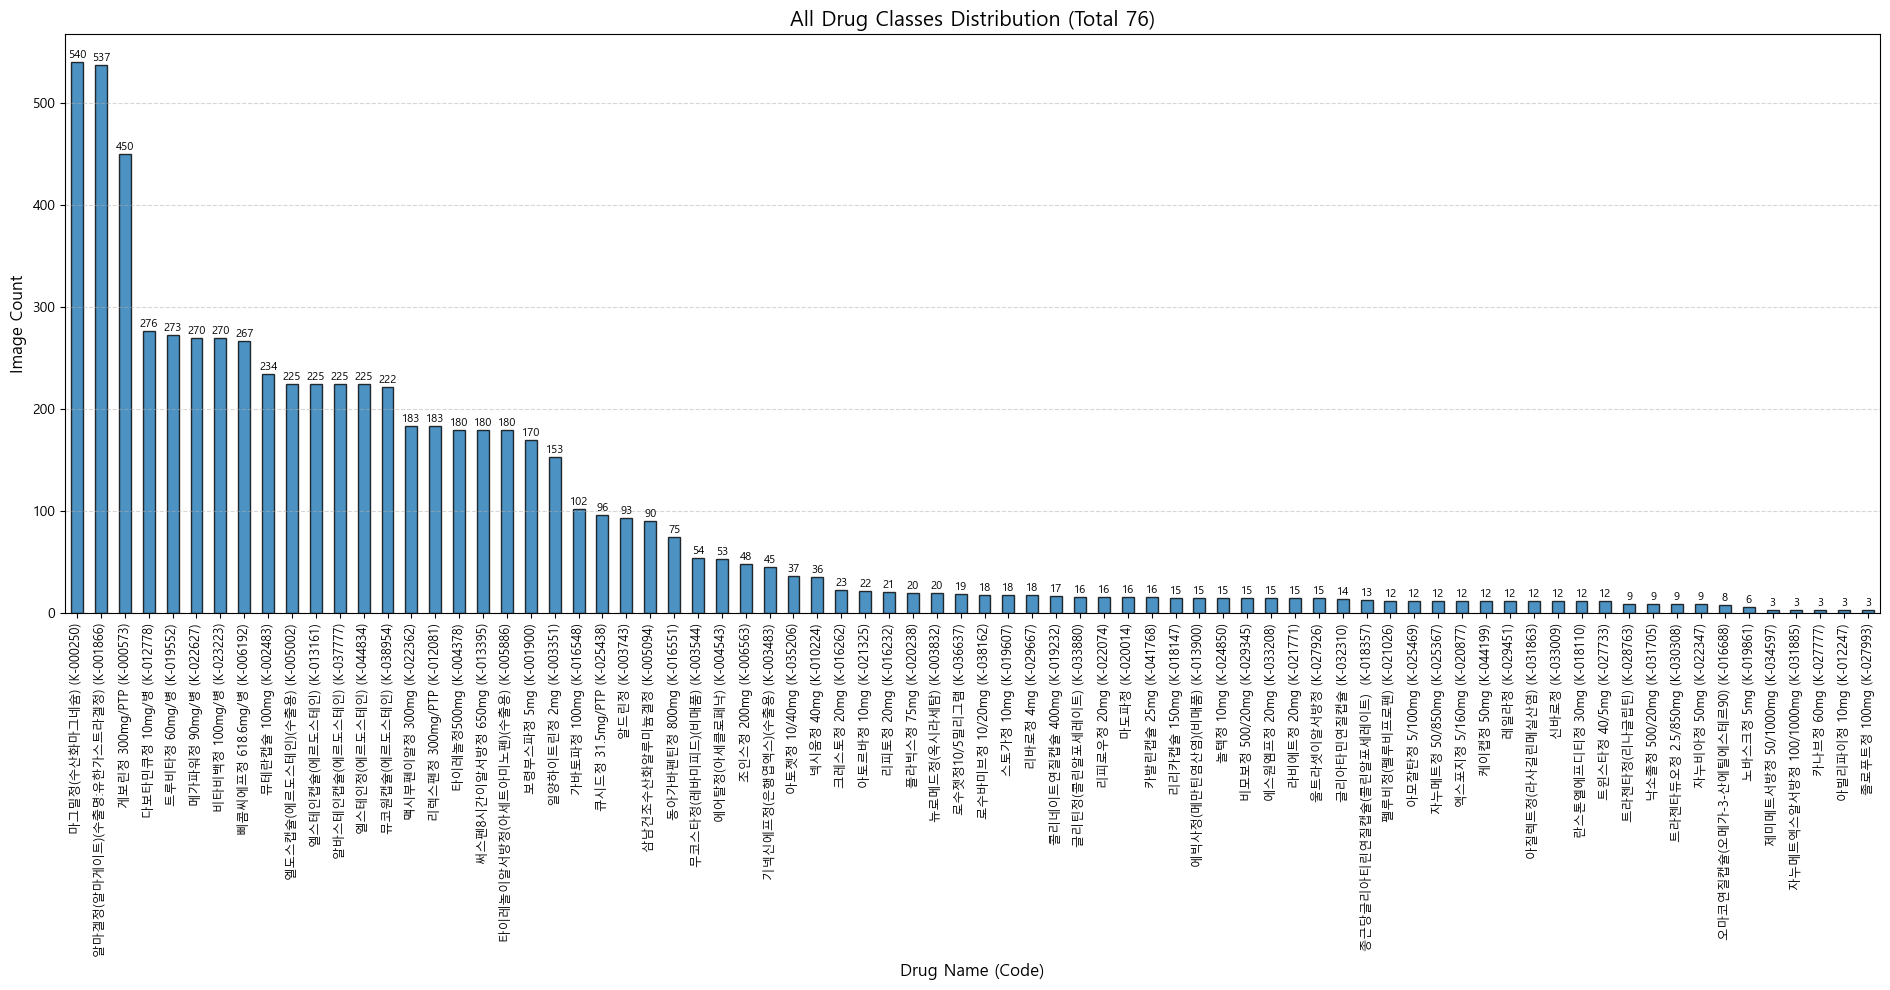

In [25]:
import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. 환경 설정 및 폰트 (한글 깨짐 방지)
# ------------------------------------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우용
plt.rcParams['axes.unicode_minus'] = False
base_path = r"C:\Users\home\Desktop\AI_study\data"

# ------------------------------------------------------------------
# 2. 데이터 처음부터 다시 싹 긁어모으기 (KeyError 방지)
# ------------------------------------------------------------------
print("데이터 전수 로딩 중... (잠시만 기다려주세요)")
all_files = glob.glob(os.path.join(base_path, "**", "*.json"), recursive=True)

data_list = []

for f_path in all_files:
    try:
        with open(f_path, 'r', encoding='utf-8') as f:
            content = json.load(f)
            
            # 데이터 위치 찾기 (images 리스트 안이나 root에 있음)
            item = {}
            if 'images' in content and isinstance(content['images'], list) and len(content['images']) > 0:
                item = content['images'][0]
            elif 'drug_N' in content:
                item = content
            
            # 핵심: 여기서 'label_name'을 직접 만듭니다.
            name = item.get('dl_name')
            code = item.get('drug_N') or item.get('dl_mapping_code')
            
            # 이름과 코드가 다 있는 경우에만 리스트에 추가
            if name and code:
                # 라벨 포맷: "약이름 (코드)"
                label = f"{name} ({code})"
                data_list.append({'label_name': label})
                
    except Exception as e:
        continue # 에러 난 파일은 무시

# ------------------------------------------------------------------
# 3. 데이터프레임 만들기
# ------------------------------------------------------------------
df = pd.DataFrame(data_list)

if df.empty:
    print("❌ 데이터를 찾을 수 없습니다. 경로를 확인해주세요.")
else:
    # ------------------------------------------------------------------
    # 4. 전체 집계 및 순번 매기기
    # ------------------------------------------------------------------
    # 개수 세기
    label_counts = df["label_name"].value_counts()
    
    # 표(DataFrame)로 변환
    counts_df = label_counts.to_frame("count")
    counts_df.index.name = "label_name"
    counts_df = counts_df.reset_index()
    
    # 순번을 0이 아니라 1부터 시작하게 설정 (No.)
    counts_df.index = counts_df.index + 1
    counts_df.index.name = "No."
    
    # ------------------------------------------------------------------
    # 5. 결과 출력 (전체 리스트)
    # ------------------------------------------------------------------
    print(f"\n📊 총 발견된 약물 클래스: {len(counts_df)}개")
    print("=" * 50)
    # 전체 리스트 표로 출력
    display(counts_df) 
    print("=" * 50)

    # ------------------------------------------------------------------
    # 6. 전체 시각화 (가로 길이 자동 조절)
    # ------------------------------------------------------------------
    # 데이터가 많으면 그래프를 옆으로 쭉 늘림 (글자 안 겹치게)
    graph_width = max(12, len(label_counts) * 0.25)
    
    plt.figure(figsize=(graph_width, 10))
    
    # 막대 그래프
    label_counts.plot(kind="bar", color='#1f77b4', edgecolor='black', alpha=0.8)
    
    plt.title(f"All Drug Classes Distribution (Total {len(label_counts)})", fontsize=15)
    plt.xlabel("Drug Name (Code)", fontsize=12)
    plt.ylabel("Image Count", fontsize=12)
    plt.xticks(rotation=90, ha="center", fontsize=9) # x축 글자 90도 회전
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # (선택) 막대 위에 숫자 표시
    for i, v in enumerate(label_counts):
        plt.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()